## Этап 0. Изучение специфики Minecraft

CLASSES (17)
'bee', 'chicken', 'cow', 'creeper', 'enderman', 'fox', 'frog', 'ghast',
'goat', 'llama', 'pig', 'sheep', 'skeleton', 'spider', 'turtle', 'wolf', 'zombie'

## Этап 1. Подготовка к выполнению проекта

In [ ]:
'''
!mkdir -p ./datasets ./artifacts/{videos,metrics,inference}
!wget -O minecraft_dataset.zip "$(curl -s 'https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key=https://disk.yandex.ru/d/ezpvkg_cdDJnNA' | python3 -c "import sys, json; print(json.load(sys.stdin)['href'])")"
!unzip minecraft_dataset.zip
!wget -P ./datasets/minecraft https://code.s3.yandex.net/deep-learning-cv/video.mp4?etag=dbd4425ca062452ae65a33312b5a9300
!wget -P checkpoints https://download.openmmlab.com/mmdetection/v2.0/fcos/fcos_r50_caffe_fpn_gn-hea
d_1x_coco/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth
'''

'\n!mkdir -p ./datasets ./artifacts/{videos,metrics,inference}\n!wget -O minecraft_dataset.zip "$(curl -s \'https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key=https://disk.yandex.ru/d/ezpvkg_cdDJnNA\' | python3 -c "import sys, json; print(json.load(sys.stdin)[\'href\'])")"\n!unzip minecraft_dataset.zip\n!wget -P ./datasets/minecraft https://code.s3.yandex.net/deep-learning-cv/video.mp4?etag=dbd4425ca062452ae65a33312b5a9300\n'

In [ ]:
'''
python3.10 -m venv practicum_venv # создание окружения 
source practicum_venv/bin/activate # активация


python3.10 -m pip install --upgrade pip setuptools wheel
pip3.10 install torch==2.1.0+cu121 torchvision==0.16.0+cu121 torchaudio==2.1.0+cu121 --index-url https://download.pytorch.org/whl/cu121


python3.10
>>> import torch
>>> torch.__version__
'2.1.0+cu121'
>>> torch.cuda.is_available()
True


pip3.10 install -U openmim
mim install mmengine
mim install "mmcv==2.1.0"

# Мы специально понижаем версию numpy для корректной установки зависимостей mmdetection
pip3.10 install numpy==1.26.4

git clone https://github.com/open-mmlab/mmdetection.git
cd mmdetection
# В mmdetection для установки с флагом -e нам придется понизить версию pip
# -e нужен для сборки в editable mode, это позволит не пересобирать 
# mmdetection после изменений, которые мы внесем
pip3.10 install pip==23.2.1
pip3.10 install -v -e . --no-build-isolation


mim download mmdet --config rtmdet_tiny_8xb32-300e_coco --dest .


python demo/image_demo.py demo/demo.jpg rtmdet_tiny_8xb32-300e_coco.py --weights rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth --device cuda
'''


In [ ]:
'''
pip3.10 install pyyaml==6.0.1
pip3.10 install opencv-python==4.8.1.78
pip3.10 install seaborn==0.13.2
pip3.10 install ultralytics==8.0.196
pip3.10 install tqdm==4.65.0
pip3.10 install fpdf2==2.7.6
'''


## Этап 2. Исследовательский анализ (EDA) и работа с данными

In [ ]:
#!apt-get install tree -y
#!tree mmdetection/datasets/ -L 2
#!C:\Windows\System32\tree.com datasets /F

In [ ]:
'''
!mkdir datasets\minecraft\annotations
!move datasets\minecraft\train\annotations.json datasets\minecraft\annotations\train_annotations.json
#заодно переименуем в valid
!move datasets\minecraft\valid\annotations.json datasets\minecraft\annotations\valid_annotations.json
!move datasets\minecraft\test\annotations.json datasets\minecraft\annotations\test_annotations.json
'''


In [ ]:
'''
!ls datasets\minecraft\annotations
!dir datasets\minecraft\annotations
'''

### Проверьте, что структура JSON корректна.

In [2]:
CLASSES = ['bee', 'chicken', 'cow', 'creeper', 'enderman', 'fox', 'frog', 'ghast',
'goat', 'llama', 'pig', 'sheep', 'skeleton', 'spider', 'turtle', 'wolf', 'zombie']

In [3]:
from scripts import check_ann_files
import json
from pathlib import Path

# Путь к папке с аннотациями
annotations_dir = Path("datasets/minecraft/annotations")
files_to_check = ["train_annotations.json", "valid_annotations.json", "test_annotations.json"]
exp_classes = CLASSES

check_ann_files (annotations_dir, files_to_check, exp_classes)


=== Проверка структуры JSON аннотаций ===

Проверка файла: train_annotations.json...
JSON синтаксически корректен (файл успешно прочитан).
Статистика датасета:
   - Изображений (images): 2307
   - Объектов/BBoxes (annotations): 4029
   - Классов (categories): 18
   - Ожидается классов (17)
   - Обнаружено классов в файле (18): ['minecraft-mobs', 'bee', 'chicken', 'cow', 'creeper']...

Проверка файла: valid_annotations.json...
JSON синтаксически корректен (файл успешно прочитан).
Статистика датасета:
   - Изображений (images): 422
   - Объектов/BBoxes (annotations): 697
   - Классов (categories): 18
   - Ожидается классов (17)
   - Обнаружено классов в файле (18): ['minecraft-mobs', 'bee', 'chicken', 'cow', 'creeper']...

Проверка файла: test_annotations.json...
JSON синтаксически корректен (файл успешно прочитан).
Статистика датасета:
   - Изображений (images): 155
   - Объектов/BBoxes (annotations): 351
   - Классов (categories): 18
   - Ожидается классов (17)
   - Обнаружено классов 

<span style="color: red;">количество классов не совпадает</span>


### ~~Проверьте, что количество изображений совпадает с количеством аннотаций.~~  
они не обязаны совпадать  
### Проверка соответствия картинок и аннотаций

In [4]:
import json
from pathlib import Path
from scripts import check_img_ann

base_dir = Path("datasets/minecraft")
annotations_dir = base_dir / "annotations"
splits = ["train", "valid", "test"]

check_img_ann (base_dir, annotations_dir, splits)


=== Проверка соответствия картинок и аннотаций ===

Сплит [TRAIN]:
   - В JSON прописано картинок: 2307
   - Всего объектов (BBoxes): 4029
   Все аннотации корректно привязаны к ID изображений.
   Все файлы изображений физически присутствуют на диске.

Сплит [VALID]:
   - В JSON прописано картинок: 422
   - Всего объектов (BBoxes): 697
   Все аннотации корректно привязаны к ID изображений.
   Все файлы изображений физически присутствуют на диске.

Сплит [TEST]:
   - В JSON прописано картинок: 155
   - Всего объектов (BBoxes): 351
   Все аннотации корректно привязаны к ID изображений.
   Все файлы изображений физически присутствуют на диске.


### Проанализируйте распределение классов: визуализируйте его и напишите вывод, есть ли дисбаланс.

=== Анализ баланса классов в датасете ===

Распределение классов для сплита: TRAIN (Всего объектов: 4029)
ID    | Название класса      | Количество | Доля (%)  
-------------------------------------------------------
0     | minecraft-mobs       | 0          | 0.00%
1     | bee                  | 86         | 2.13%
2     | chicken              | 835        | 20.72%
3     | cow                  | 661        | 16.41%
4     | creeper              | 177        | 4.39%
5     | enderman             | 22         | 0.55%
6     | fox                  | 111        | 2.76%
7     | frog                 | 111        | 2.76%
8     | ghast                | 127        | 3.15%
9     | goat                 | 102        | 2.53%
10    | llama                | 135        | 3.35%
11    | pig                  | 884        | 21.94%
12    | sheep                | 94         | 2.33%
13    | skeleton             | 177        | 4.39%
14    | spider               | 170        | 4.22%
15    | turtle               |

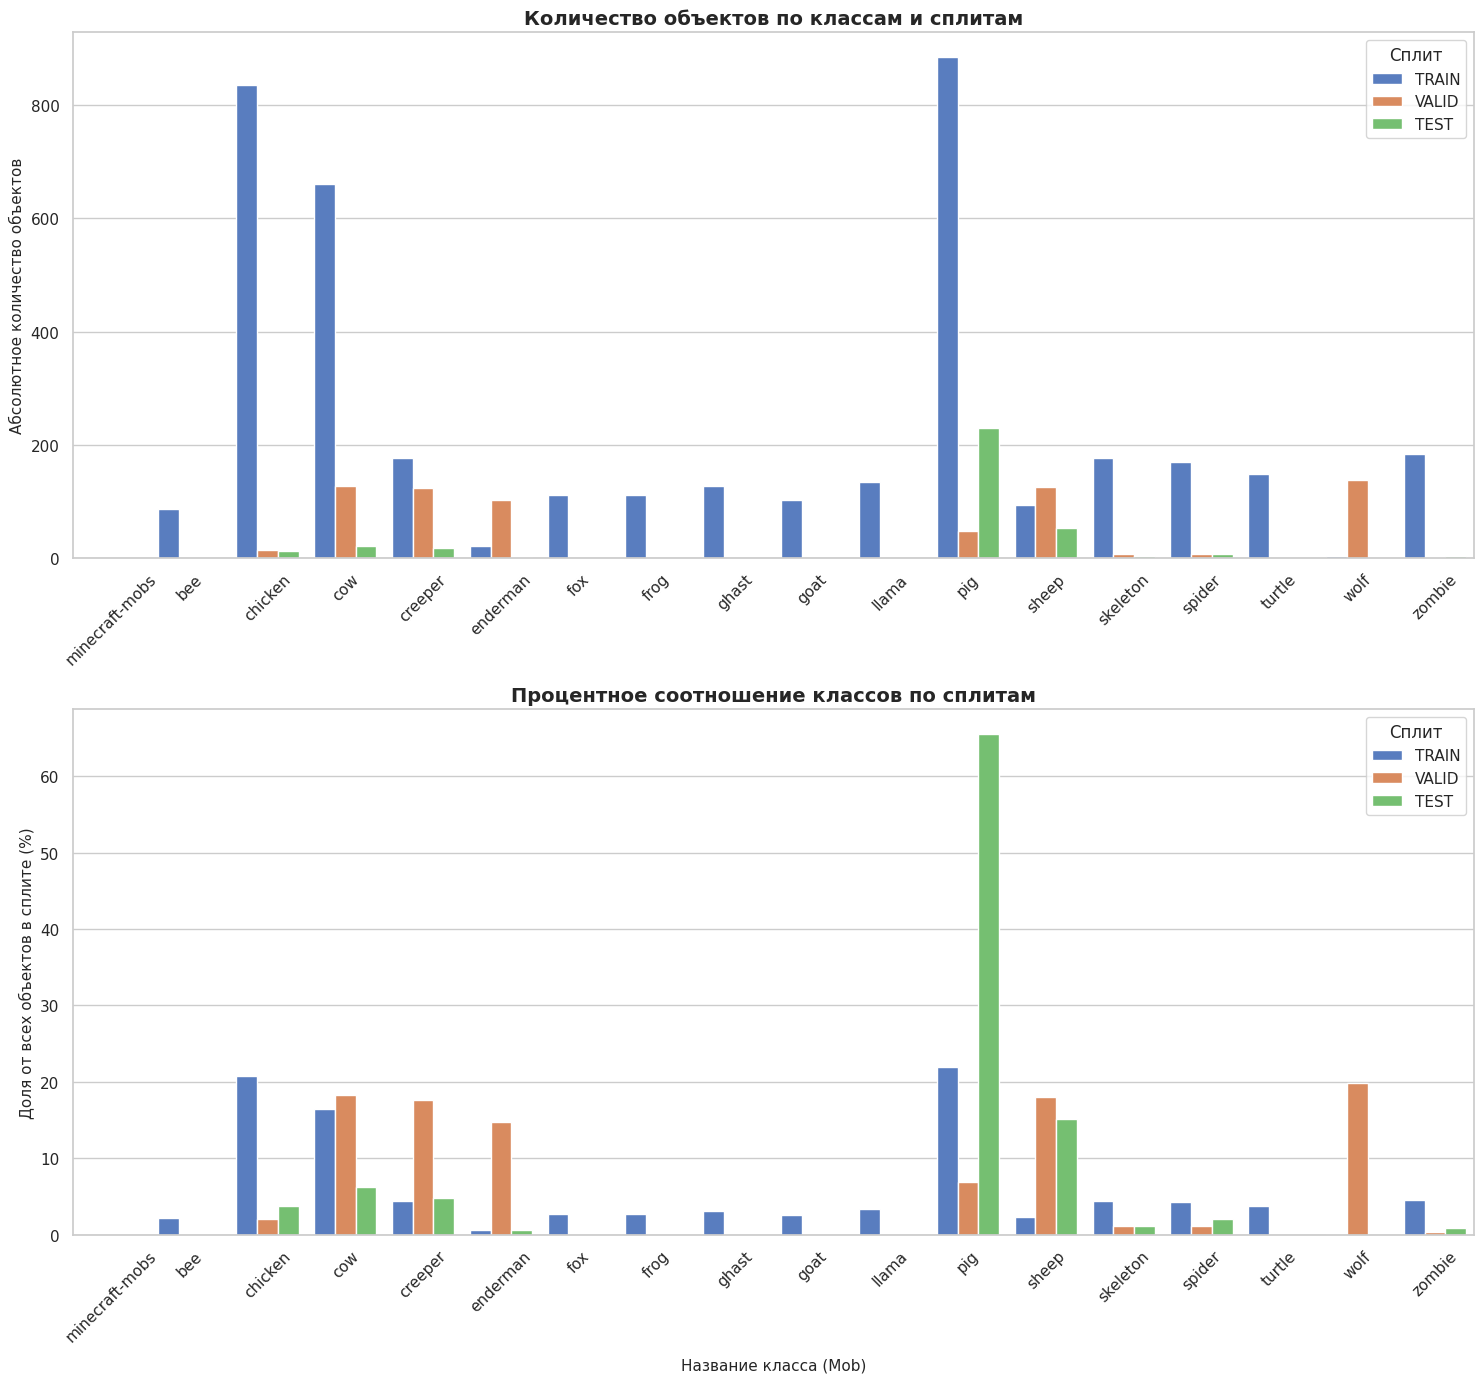


[INFO] Графики распределения сохранены в: artifacts/class_distribution_combined.png


In [5]:
from pathlib import Path
from scripts import cls_dispersion

# Пути к данным
annotations_dir = Path("datasets/minecraft/annotations")
splits = ["train", "valid", "test"]


cls_dispersion (annotations_dir, splits)
    

- Классы- призраки во валидации: Классы bee, fox, frog, ghast, goat, llama, turtle имеют объекты в TRAIN, но полностью отсутствуют (0 объектов) в VALID и TEST. Модели научатся их детектировать, но метрики (mAP) по ним вы не узнаете. 
- Аномалия с классом wolf: В TRAIN всего 4 волка (0.10%), зато в VALID их аж 138 (19.80%), а в TEST снова 0. Модель физически не сможет выучить этот класс по 4 примерам, и валидация на нем полностью провалится. 
- Перекос TEST сплита: В TEST выборке класс pig занимает 65.53% всех объектов. Оценка mAP будет отражать только качество детектирования свиней. 
- Пустой класс: Класс minecraft-mobs равен 0 везде. Его нужно удалить из конфигурации (оставить 17 классов вместо 18).

### Визуализируйте один тестовый пример. Отрисуйте одно тестовое изображение с выделенными на нём bounding box'ами и подписанными классами

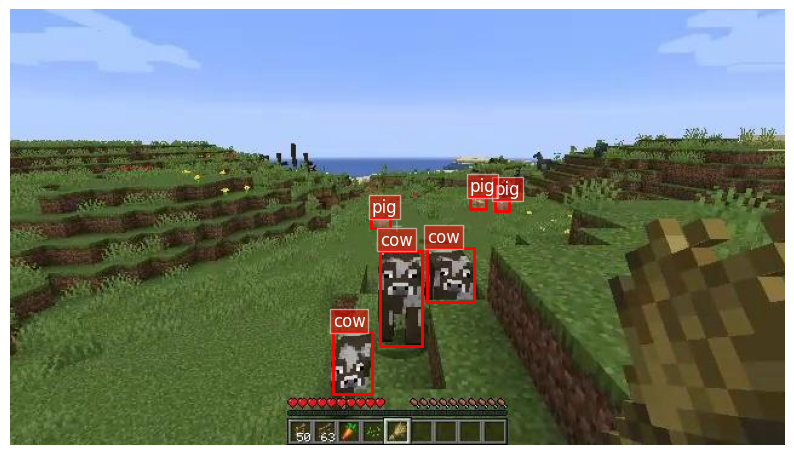

In [6]:
from scripts import vis_test
from pathlib import Path


annotations_dir = Path("datasets/minecraft/annotations/")
image_dir = Path("datasets/minecraft/test")


vis_test(annotations_dir, image_dir)
    

In [7]:

from pathlib import Path
from scripts import img_per_obj

annotations_dir = Path("datasets/minecraft/annotations/")

img_per_obj(annotations_dir)
    

Класс                | Кол-во уникальных картинок
--------------------------------------------------
pig                  | 80                       
sheep                | 43                       
creeper              | 17                       
cow                  | 10                       
spider               | 7                        
chicken              | 5                        
skeleton             | 4                        
zombie               | 2                        
enderman             | 2                        
--------------------------------------------------
Всего изображений в датасете: 155
Из них имеют хотя бы одну аннотацию: 155


### Проверяем сам датасет

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Путь к изображению: datasets/minecraft/train/snow_-_pig_1215_jpg.rf.004b081d444fa45d89e051a2d793ac9c.jpg


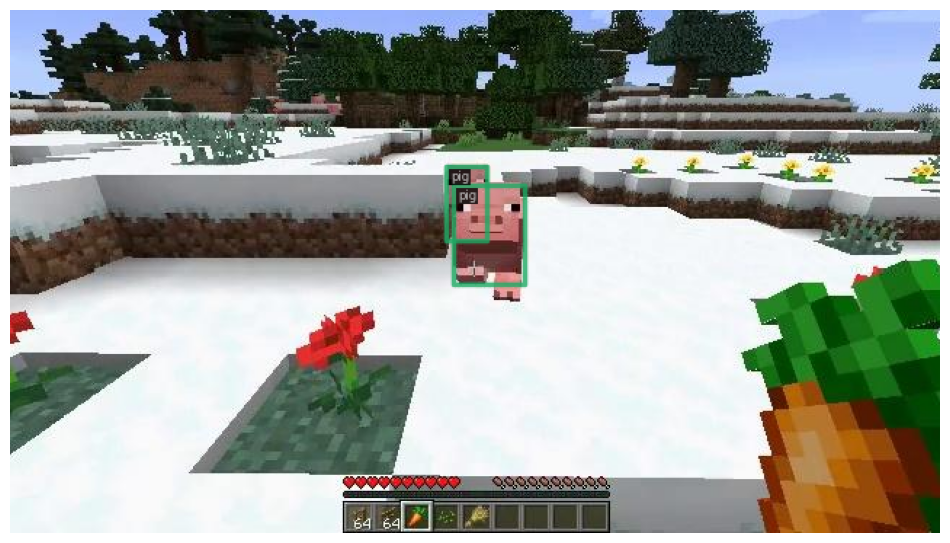

In [11]:
from dataset_demonstration import visialize_sample

visialize_sample()

## Этап 3. Настройка конфигурации моделей

configs/fcos/fcos_minecraft.py  
mmdet/datasets/coco_minecraft.py

### Перед обучением протестируйте инференс на pretrained-модели FCOS в ноутбуке.

Loads checkpoint by local backend from path: checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth
The model and loaded state dict do not match exactly

size mismatch for bbox_head.conv_cls.weight: copying a param with shape torch.Size([80, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([18, 256, 3, 3]).
size mismatch for bbox_head.conv_cls.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([18]).


/home/ubuntu/practicum_venv/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/home/ubuntu/practicum_venv/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '
/home/ubuntu/practicum_venv/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:760: UserWarning: Warning: The bbox is out of bounds, the drawn bbox may not be in the image
  warnings.warn(
/home/ubuntu/practicum_venv/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:831: UserWarning: Warning: The polygon is out of bounds, the drawn polygon may not be 

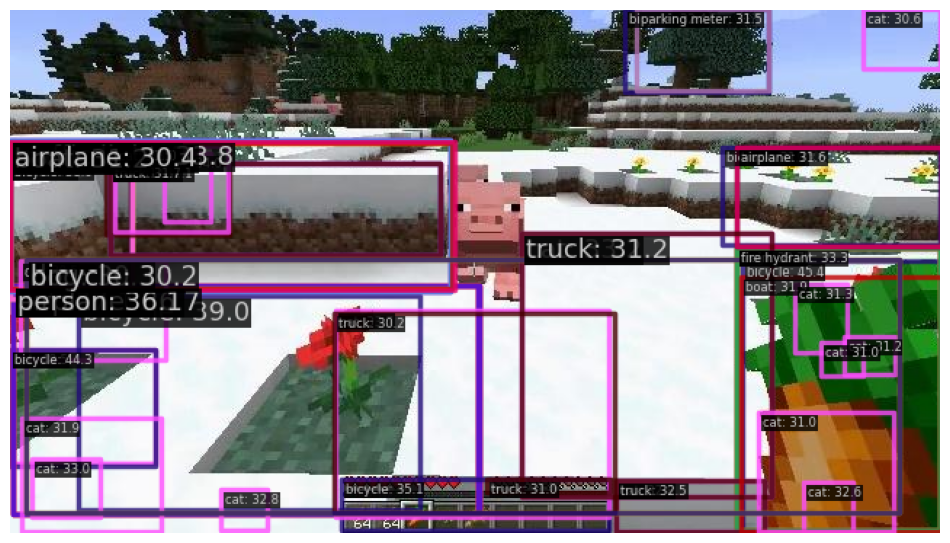

In [12]:
from test_inference_pt import test_inference_pt

test_inference_pt()

### Сначала подготовьте файл datasets/minecraft/data.yaml, чтобы YOLO работал с данными в корректной форме

datasets/minecraft/data.yaml

### Проверьте инференс на pretrained-модели YOLOv8s. Именно её вы будете дообучать. 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/ubuntu/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 384x640 1 person, 3 potted plants, 1 dining table, 62.6ms
Speed: 1.8ms preprocess, 62.6ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)


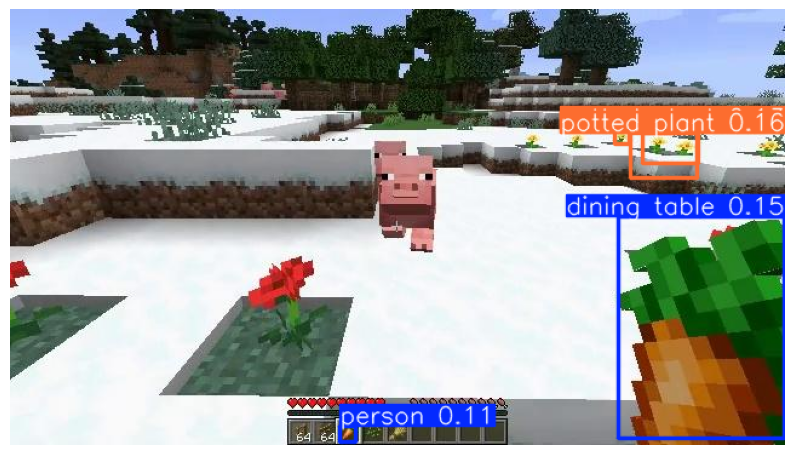

In [1]:
from test_inference_pt_yolo import test_inference_pt_yolo

test_inference_pt_yolo()

## Этап 4. Обучение моделей

### FCOS/MMdetection

In [1]:
import mmcv
from mmengine.config import Config
from mmengine.runner import Runner

config = 'configs/fcos/fcos_minecraft.py'

cfg = Config.fromfile(config)

# print(cfg.pretty_text) # Выведет весь конфиг для проверки
runner = Runner.from_cfg(cfg)
runner.train()


07/06 13:56:52 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1201689798
    GPU 0: Tesla T4
    CUDA_HOME: /usr
    NVCC: Cuda compilation tools, release 12.2, V12.2.140
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0
    PyTorch: 2.1.0+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-ge

/home/ubuntu/practicum_venv/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


07/06 13:57:09 - mmengine - INFO - Epoch(train)  [1][  50/1154]  base_lr: 4.9850e-04 lr: 4.9850e-04  eta: 0:25:33  time: 0.1112  data_time: 0.0088  memory: 599  grad_norm: inf  loss: 3.9407  loss_cls: 0.9057  loss_bbox: 2.3589  loss_centerness: 0.6762
07/06 13:57:13 - mmengine - INFO - Epoch(train)  [1][ 100/1154]  base_lr: 5.8200e-04 lr: 5.8200e-04  eta: 0:20:43  time: 0.0697  data_time: 0.0043  memory: 599  grad_norm: 29.0246  loss: 2.6549  loss_cls: 0.8278  loss_bbox: 1.1809  loss_centerness: 0.6462
07/06 13:57:16 - mmengine - INFO - Epoch(train)  [1][ 150/1154]  base_lr: 6.6550e-04 lr: 6.6550e-04  eta: 0:19:15  time: 0.0722  data_time: 0.0045  memory: 599  grad_norm: 23.7245  loss: 2.4412  loss_cls: 0.7458  loss_bbox: 1.0485  loss_centerness: 0.6468
07/06 13:57:20 - mmengine - INFO - Epoch(train)  [1][ 200/1154]  base_lr: 7.4900e-04 lr: 7.4900e-04  eta: 0:18:22  time: 0.0702  data_time: 0.0044  memory: 599  grad_norm: 24.1064  loss: 2.4300  loss_cls: 0.6882  loss_bbox: 1.0927  loss

FCOS(
  (data_preprocessor): DetDataPreprocessor()
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): ResLayer(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
   

### Визуализация FCOS обучения

Всего строк в логе: 288
Строк обучения (с loss): 276
Строк валидации (с mAP): 12


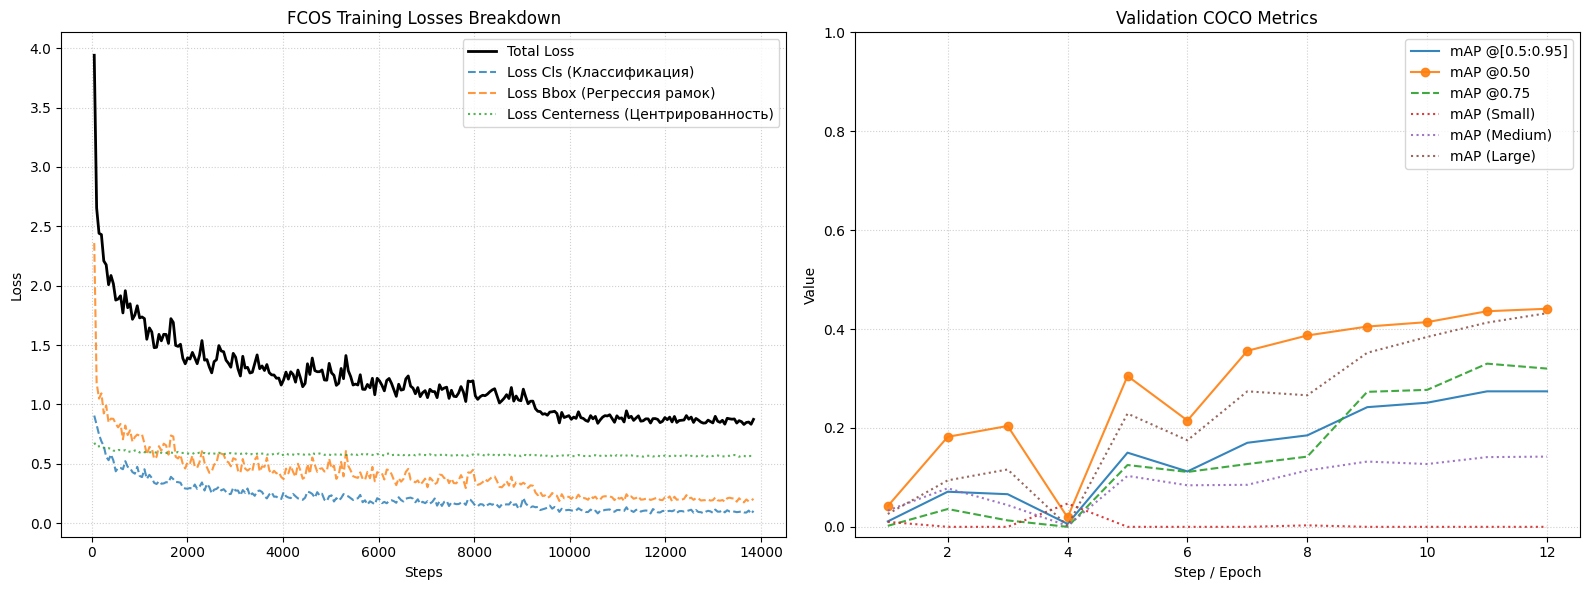

In [1]:
from viz_fcos import viz_fcos

viz_fcos()
    


### YOLOv8/Ultralytics

In [6]:
from ultralytics.data.converter import convert_coco

convert_coco(labels_dir='datasets/minecraft/annotations/', use_segments=False, cls91to80=False)


Annotations /home/ubuntu/mmdetection/datasets/minecraft/annotations/test_annotations.json: 100% ━━━━━━━━━━━━ 155/155 7.7Kit/s 0.0s


Annotations /home/ubuntu/mmdetection/datasets/minecraft/annotations/train_annotations.json: 100% ━━━━━━━━━━━━ 2307/2307 9.0Kit/s 0.3s0.1s
Annotations /home/ubuntu/mmdetection/datasets/minecraft/annotations/valid_annotations.json: 100% ━━━━━━━━━━━━ 422/422 8.0Kit/s 0.1s
COCO data converted successfully.
Results saved to /home/ubuntu/mmdetection/coco_converted-4


In [3]:
import torch
from ultralytics import YOLO

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_yolo = YOLO('yolov8s.pt').to(device)

results = model_yolo.train(
        data='datasets/minecraft/data.yaml',
        epochs=25,
        project = './artifacts/',
        name='yolo',
        exist_ok=True,
        imgsz=(512,512),
        batch=2,
        patience=20,
        seed=42,
        device=device,
        hsv_h=0.015,   # <- Применяем цветовые аугментации
        fliplr=0.5,    # <- Применяем отражение
        mosaic=1.0     # <- Применяем мозаику
        ) 
    

Ultralytics 8.4.89 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (Tesla T4, 14931MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/minecraft/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=(512, 512), iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

### Визуализация YOLO обучения

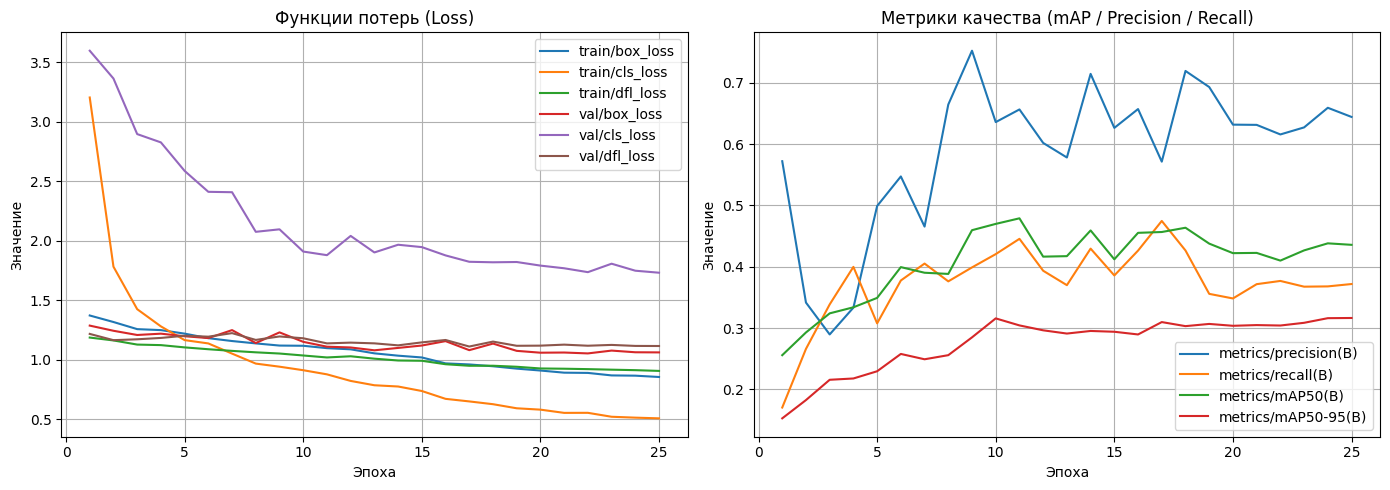

In [6]:
from viz_yolo import viz_yolo

viz_yolo()


## Этап 5. Инференс моделей

### Прогоните обученные модели на тестовых изображениях для FCOS и YOLO в ячейках ноутбука.

In [1]:
!python tools/test.py \
    configs/fcos/fcos_minecraft.py \
    artifacts/fcos/best_coco_bbox_mAP_epoch_11.pth \
    --work-dir artifacts/inference/fcos \
    --show-dir images


07/08 17:19:54 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
    CUDA available: False
    MUSA available: False
    numpy_random_seed: 96146988
    MSVC: Microsoft (R) C/C++ Optimizing Compiler Version 19.51.36244 for x64
    GCC: n/a
    PyTorch: 2.0.0+cpu
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 193431937
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - Build settings: BLAS_INFO=mkl, BUILD_TYPE=Release, CXX_COMPILER=C:/actions-runner/_work/pytorch/pytorch/builder/windows/tmp_bin/sccache-cl.exe, CXX_FLAGS=/DWIN32 /D_WINDOWS /GR /

c:\Users\esalmin\dev\dl_training\CV1\mmdetetion_workspace\.venv\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
c:\Users\esalmin\dev\dl_training\CV1\mmdetetion_workspace\.venv\lib\site-packages\mmengine\visualization\visualizer.py:760: UserWarning: Warning: The bbox is out of bounds, the drawn bbox may not be in the image
  warnings.warn(
c:\Users\esalmin\dev\dl_training\CV1\mmdetetion_workspace\.venv\lib\site-packages\mmengine\visualization\visualizer.py:831: UserWarning: Warning: The polygon is out of bounds, the drawn polygon may not be in the image
  warnings.warn(
